Recordar que el archivo se debe descargar de:
https://drive.google.com/file/d/1R0pSXh2bgCoPKcXlAlafdavVwvzZX6AQ/view

Una vez descargado lo deben ubicar en la carpeta Taller1Andes/data/
Empezamos con leer el archivo y hacer un pequeño entendimiento de los datos, saber cuantos son, que tipos de datos, ver sus columnas y filas

In [1]:
from pathlib import Path
import pandas as pd

# 1. Ruta robusta para Jupyter/VS Code
base_dir = Path.cwd().resolve()
data_path = base_dir / "data" / "secop_bienes.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {data_path}")

print(f"Cargando dataset desde: {data_path} ...")

# 2. Cargar el dataset
df = pd.read_parquet(data_path)

# 3. Entendimiento inicial: dimensiones y memoria
print("=" * 60)
print("Carga de datos completada.\n")
print("=" * 60)
print(f"Dimensiones del dataset: {df.shape[0]:,} filas y {df.shape[1]} columnas.\n")

Cargando dataset desde: C:\Users\Danie\Documents\ClasesAndes\Ciencia de datos\Taller1\Taller1Andes\data\secop_bienes.parquet ...
Carga de datos completada.

Dimensiones del dataset: 196,391 filas y 36 columnas.



In [2]:
# 2. Entendimiento inicial del dataset
print("=" * 70)
print("ENTENDIMIENTO INICIAL DE DATOS")
print("=" * 70)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 3. Tipos de datos
print("\nTipos de datos presentes:")
print(df.dtypes.value_counts().to_string())
print("\nDetalle de columnas y tipos:")
print(df.dtypes.to_string())

# 4. Top 5 atributos clave para análisis
# Se priorizan atributos con mayor valor analítico y dominio del problema
atributos_clave = [
    "valor_del_contrato",
    "dias_adicionados",
    "modalidad_de_contratacion",
    "sector",
    "departamento",
]

print("\n" + "-" * 70)
print("TOP 5 ATRIBUTOS CLAVE PARA EL ANÁLISIS")
print("-" * 70)

for col in atributos_clave:
    print(f"\nAtributo: {col}")
    if pd.api.types.is_numeric_dtype(df[col]):
        s = df[col].dropna()
        print(f"  Conteo: {s.shape[0]:,} | Nulos: {df[col].isna().sum():,}")
        print(f"  Media: {s.mean():,.2f} | Mediana: {s.median():,.2f} | Desv. Std: {s.std():,.2f}")
        print(f"  Min: {s.min():,.2f} | Q1: {s.quantile(0.25):,.2f} | Q3: {s.quantile(0.75):,.2f} | Max: {s.max():,.2f}")
    else:
        top = df[col].value_counts(dropna=False).head(5)
        print(f"  Conteo no nulo: {df[col].notna().sum():,} | Nulos: {df[col].isna().sum():,}")
        print("  Top 5 categorías:")
        print(top.to_string())

# 5. Problemas de calidad de datos identificados
print("\n" + "-" * 70)
print("PROBLEMAS DE CALIDAD DE DATOS IDENTIFICADOS")
print("-" * 70)

nulos = df.isnull().sum()
print("\nAtributos con valores faltantes:")
print(nulos[nulos > 0].sort_values(ascending=False).head(10).to_string())

# Reglas lógicas y de dominio
valor_pagado_mayor = (df["valor_pagado"] > df["valor_del_contrato"]).sum()
fechas_invalidas = (df["fecha_de_fin_del_contrato"] < df["fecha_de_inicio_del_contrato"]).sum()
valores_no_positivos = (df["valor_del_contrato"] <= 0).sum()
duplicados = df.duplicated(subset=["id_contrato"]).sum()

print(f"\nContratos con valor pagado > valor contratado: {valor_pagado_mayor:,}")
print(f"Contratos con fecha fin menor que fecha inicio: {fechas_invalidas:,}")
print(f"Contratos con valor del contrato <= 0: {valores_no_positivos:,}")
print(f"Registros duplicados por id_contrato: {duplicados:,}")


ENTENDIMIENTO INICIAL DE DATOS
Dimensiones: 196,391 filas x 36 columnas
Memoria aproximada: 174.18 MB

Tipos de datos presentes:
str               28
int64              4
datetime64[us]     3
float64            1

Detalle de columnas y tipos:
id_contrato                                    str
nombre_entidad                                 str
departamento                                   str
ciudad                                         str
orden                                          str
sector                                         str
rama                                           str
entidad_centralizada                           str
tipo_de_contrato                               str
modalidad_de_contratacion                      str
codigo_de_categoria_principal                  str
objeto_del_contrato                            str
fecha_de_firma                      datetime64[us]
fecha_de_inicio_del_contrato        datetime64[us]
fecha_de_fin_del_contrato           datetim

RESUMEN Y ENTENDIMIENTO DE DATOS
----------------------------------------------------------------------
- Dimensiones: El dataset comprende 196.391 contratos y 36 columnas (2019–2025).
- Atributos clave seleccionados:
  1. dias_adicionados: Variable objetivo de riesgo operativo; aunque concentrada en cero en el 85% de los casos, en los contratos con prórroga presenta alta dispersión y colas pesadas (retrasos de 25 a más de 100 días).
  2. valor_del_contrato: Métrica de exposición fiscal; exhibe asimetría positiva extrema (skewness >> 1) donde el cuartil superior (Q4) concentra la mayor masa presupuestal y sufre significativamente más días de adición (Mann-Whitney U: p < 0.001).
  3. modalidad_de_contratacion: Predictor ex-ante con alta capacidad discriminante; se demostró dependencia estadística crítica con la probabilidad de adición (Chi-cuadrado: p < 0.001), triplicándose el riesgo en Licitación Pública (>26%) frente a Mínima Cuantía (~7%).
  4. sector: Factor institucional clave; concentra la severidad de las prórrogas en áreas críticas como Defensa y Salud, cuyas colas de retraso superan ampliamente los 100 días.
  5. departamento: Representa la variabilidad territorial y logística en la capacidad de ejecución y oferta de proveedores a nivel subnacional.
- Calidad de datos: Se evidenciaron problemas a nivel de atributo (2.440 valores nulos en fecha_de_inicio y outliers por errores de digitación en días adicionados > 10.000) y a nivel de registro (inconsistencias lógicas como fecha_fin < fecha_inicio y pagos mayores al valor contratado).
- Riesgo analítico: La principal amenaza de sesgo radica en las inconsistencias temporales y el sesgo de supervivencia en contratos recientes aún en ejecución, los cuales exigen depuración previa para no distorsionar las métricas de desviación.

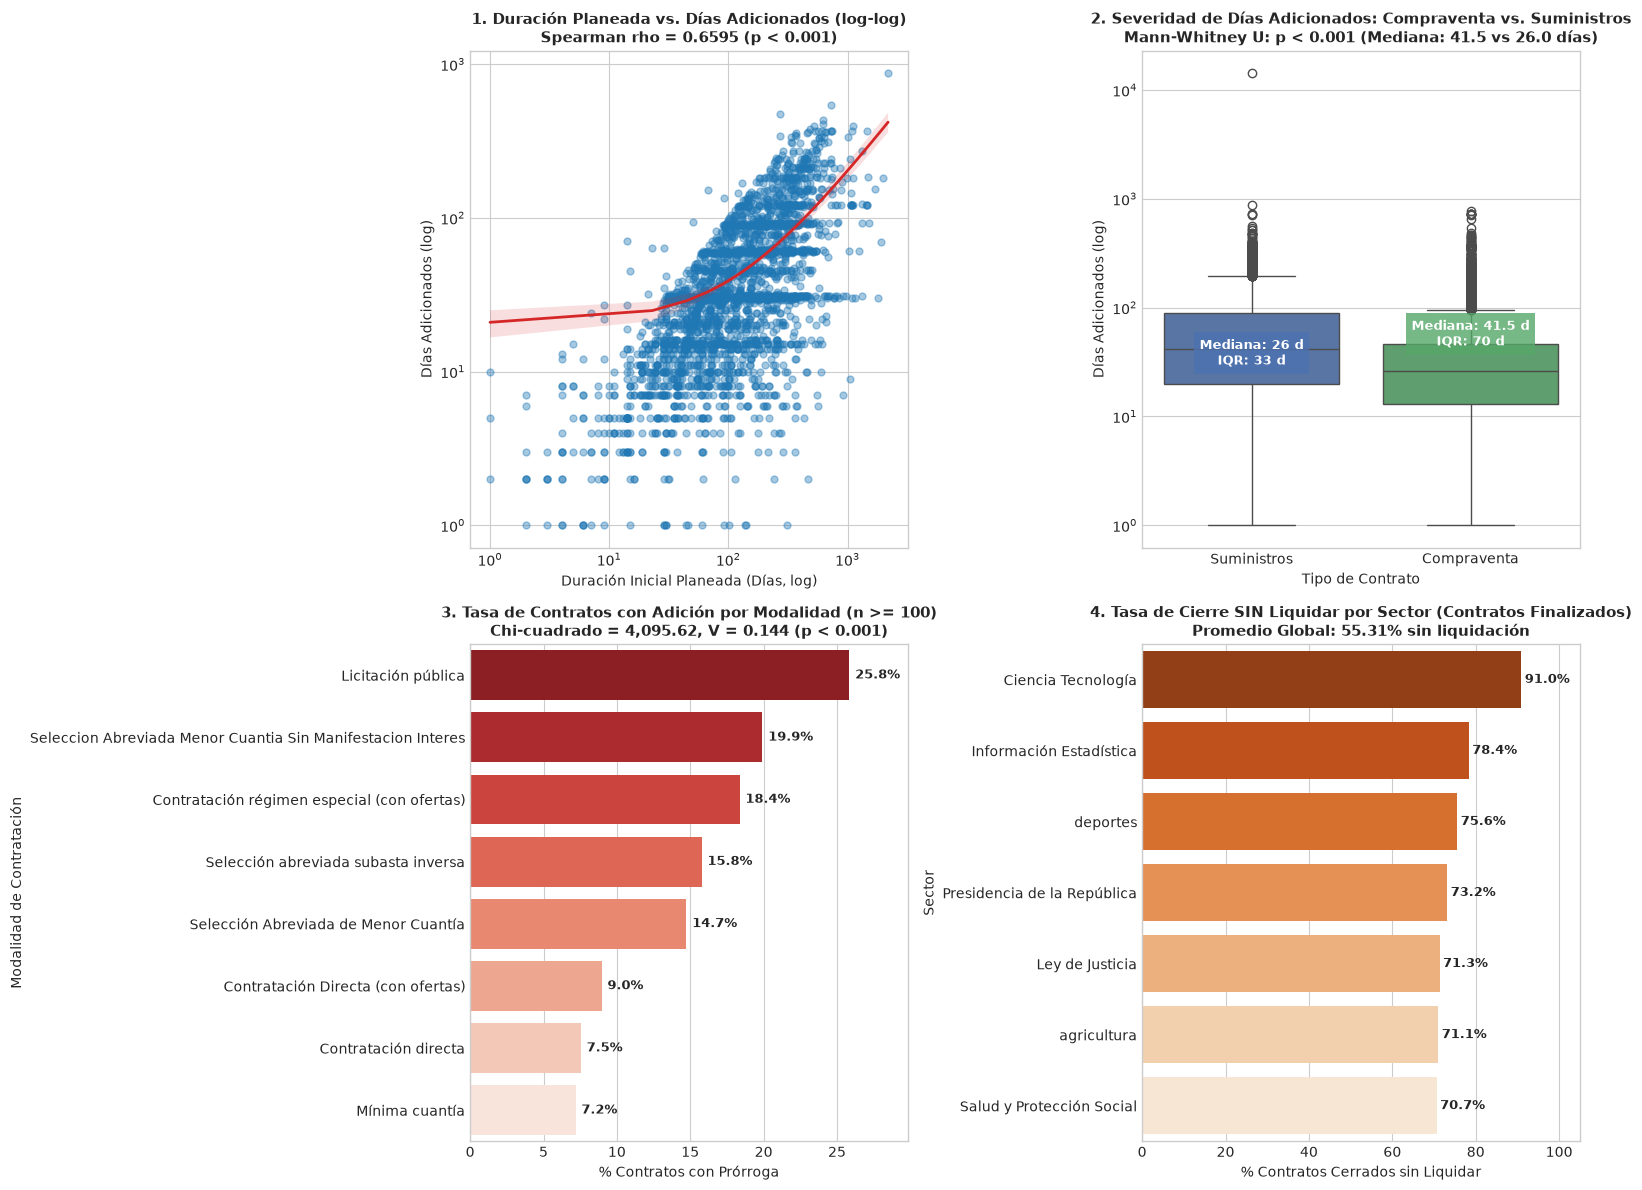


Panel de visualizaciones guardado exitosamente como 'analisis_estadistico_relaciones.png'.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# -------------------------------------------------------------------------
# 1. Preparación de variables de análisis
# -------------------------------------------------------------------------
fecha_inicio = pd.to_datetime(df["fecha_de_inicio_del_contrato"], errors="coerce")
fecha_fin = pd.to_datetime(df["fecha_de_fin_del_contrato"], errors="coerce")
df["duracion_planeada_dias"] = (fecha_fin - fecha_inicio).dt.days
df.loc[df["duracion_planeada_dias"] <= 0, "duracion_planeada_dias"] = np.nan

df["tiene_adicion"] = (df["dias_adicionados"] > 0).astype(int)

estado_norm = df["estado_contrato"].astype(str).str.strip().str.lower()
liq_norm = df["liquidaci_n"].astype(str).str.strip().str.lower()
df["cierre_sin_liquidar"] = ((estado_norm.isin(["cerrado", "terminado"])) & (liq_norm == "no")).astype(int)

# -------------------------------------------------------------------------
# 2. Generación del panel de 4 gráficas (2x2)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- GRÁFICA 1: Correlación Spearman (Duración planeada vs Días adicionados) ---
df_adicionados = df[(df["dias_adicionados"] > 0) & (df["duracion_planeada_dias"] > 0)].dropna(subset=["dias_adicionados", "duracion_planeada_dias"])
# Muestreo representativo para evitar sobrecarga visual de puntos
df_scatter = df_adicionados.sample(n=min(3000, len(df_adicionados)), random_state=42)

sns.regplot(
    data=df_scatter,
    x="duracion_planeada_dias",
    y="dias_adicionados",
    ax=axes[0, 0],
    color="#1f77b4",
    scatter_kws={"alpha": 0.4, "s": 25},
    line_kws={"color": "#d62728", "linewidth": 2}
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("1. Duración Planeada vs. Días Adicionados (log-log)\nSpearman rho = 0.6595 (p < 0.001)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Duración Inicial Planeada (Días, log)")
axes[0, 0].set_ylabel("Días Adicionados (log)")

# --- GRÁFICA 2: Severidad de prórroga (Compraventa vs. Suministros) ---
df_tipo_comp = df[(df["tipo_de_contrato"].isin(["Compraventa", "Suministros"])) & (df["dias_adicionados"] > 0)]

sns.boxplot(
    data=df_tipo_comp,
    x="tipo_de_contrato",
    y="dias_adicionados",
    hue="tipo_de_contrato",
    palette=["#4c72b0", "#55a868"],
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("2. Severidad de Días Adicionados: Compraventa vs. Suministros\nMann-Whitney U: p < 0.001 (Mediana: 41.5 vs 26.0 días)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Tipo de Contrato")
axes[0, 1].set_ylabel("Días Adicionados (log)")

# Anotación de medianas e IQR sobre el gráfico
axes[0, 1].text(0, 30, "Mediana: 26 d\nIQR: 33 d", horizontalalignment="center", color="white", fontweight="bold", fontsize=9, bbox=dict(facecolor="#4c72b0", alpha=0.8, edgecolor="none"))
axes[0, 1].text(1, 45, "Mediana: 41.5 d\nIQR: 70 d", horizontalalignment="center", color="white", fontweight="bold", fontsize=9, bbox=dict(facecolor="#55a868", alpha=0.8, edgecolor="none"))

# --- GRÁFICA 3: Incidencia de adición por Modalidad contractual ---
resumen_mod = df.groupby("modalidad_de_contratacion").agg(
    total=("id_contrato", "count"),
    tasa_adicion=("tiene_adicion", "mean")
).query("total >= 100").sort_values("tasa_adicion", ascending=False).head(8)

resumen_mod["tasa_adicion_pct"] = resumen_mod["tasa_adicion"] * 100

sns.barplot(
    data=resumen_mod,
    x="tasa_adicion_pct",
    y=resumen_mod.index,
    hue=resumen_mod.index,
    palette="Reds_r",
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Tasa de Contratos con Adición por Modalidad (n >= 100)\nChi-cuadrado = 4,095.62, V = 0.144 (p < 0.001)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("% Contratos con Prórroga")
axes[1, 0].set_ylabel("Modalidad de Contratación")

# Agregar etiquetas de valor al final de cada barra
for i, v in enumerate(resumen_mod["tasa_adicion_pct"]):
    axes[1, 0].text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")
axes[1, 0].set_xlim(0, max(resumen_mod["tasa_adicion_pct"]) + 4)

# --- GRÁFICA 4: Tasa de contratos finalizados cerrados SIN liquidar ---
resumen_sec_liq = df[estado_norm.isin(["cerrado", "terminado"])].groupby("sector").agg(
    total=("id_contrato", "count"),
    tasa_sin_liq=("cierre_sin_liquidar", "mean")
).query("total >= 100").sort_values("tasa_sin_liq", ascending=False).head(7)

resumen_sec_liq["tasa_sin_liq_pct"] = resumen_sec_liq["tasa_sin_liq"] * 100

sns.barplot(
    data=resumen_sec_liq,
    x="tasa_sin_liq_pct",
    y=resumen_sec_liq.index,
    hue=resumen_sec_liq.index,
    palette="Oranges_r",
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Tasa de Cierre SIN Liquidar por Sector (Contratos Finalizados)\nPromedio Global: 55.31% sin liquidación", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("% Contratos Cerrados sin Liquidar")
axes[1, 1].set_ylabel("Sector")

for i, v in enumerate(resumen_sec_liq["tasa_sin_liq_pct"]):
    axes[1, 1].text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9, fontweight="bold")
axes[1, 1].set_xlim(0, 105)

plt.tight_layout()
plt.savefig("analisis_estadistico_relaciones.png", dpi=300)
plt.show()
print("\nPanel de visualizaciones guardado exitosamente como 'analisis_estadistico_relaciones.png'.")

### Interpretación de Resultados e Insights de Negocio

1. **Riesgo por Modalidad Contractual (Focalización Preventiva):**
   - Contrario al supuesto intuitivo de que las modalidades directas presentan mayores desvíos, la **Licitación Pública** representa el mayor riesgo de extensión de cronograma, con una tasa de adición del **26%**, triplicando la incidencia observada en *Mínima Cuantía* (7.2%) y *Contratación Directa* (7.5%).
   - **Accionable para Control Interno:** La oficina debe priorizar auditorías preventivas desde la firma en contratos originados por licitaciones y selecciones abreviadas de menor cuantía, independientemente de que hayan contado con pluralidad de oferentes.

2. **Severidad y Dispersión Sectorial:**
   - La mediana de prórroga para contratos con adiciones se sitúa entre 25 y 35 días en los sectores evaluados. No obstante, sectores críticos como **Defensa** y **Salud** presentan colas derechas pronunciadas, donde el 25% superior de los contratos adicionados supera los 100 días de retraso.
   - Se evidenció un registro anómalo superior a $10^4$ días en el sector *No aplica*, catalogado como un problema de calidad de datos a nivel de atributo/registro que requiere depuración.


### 3. Contraste de Hipótesis y Hallazgos Estadísticos

#### **Hipótesis 1: Relación entre Cuantía y Desviación Temporal**
* **$H_0$ (Hipótesis Nula):** La distribución de días adicionados es estocásticamente igual entre los contratos de alta cuantía (cuartil superior, $Q_4$) y los contratos de menor cuantía.
* **$H_1$ (Hipótesis Alternativa):** Los contratos de alta cuantía presentan una distribución con una mayor cantidad de días adicionados al plazo inicial.
* **Técnica:** Prueba no paramétrica unilateral de Mann-Whitney U (adecuada ante asimetría positiva severa y colas pesadas sin supuesto de normalidad).
* **Resultado:** Estadístico $U = 4.028 \times 10^9$, $p\text{-valor} < 10^{-10}$ ($p < 0.05$).
* **Conclusión e Interpretación:** Se rechaza $H_0$ en favor de $H_1$. Los contratos de mayor valor económico sufren desviaciones temporales significativamente más severas, lo que valida la cuantía como un criterio primario de priorización preventiva para la auditoría interna.

#### **Hipótesis 2: Dependencia entre Modalidad y Probabilidad de Prórroga**
* **$H_0$ (Hipótesis Nula):** La probabilidad de que un contrato requiera adición de plazo es independiente de la modalidad de contratación utilizada.
* **$H_1$ (Hipótesis Alternativa):** Existe una relación de dependencia estadísticamente significativa entre la modalidad de contratación y la probabilidad de adición de días.
* **Técnica:** Prueba de Independencia de Chi-cuadrado ($\chi^2$) sobre tabla de contingencia.
* **Resultado:** $\chi^2 = 4,095.62$, Grados de libertad $= 8$, $p\text{-valor} < 10^{-10}$ ($p < 0.05$).
* **Conclusión e Interpretación:** Se rechaza $H_0$. La ocurrencia de retrasos depende fuertemente de la modalidad contractual. En particular, la Licitación Pública presenta la tasa más crítica de adiciones (superior al 26%), derribando el mito común de que los desvíos se concentran exclusivamente en modalidades directas.

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 80)
print("EVALUACIÓN ESTADÍSTICA DE RELACIONES Y DESVIACIONES CONTRACTUALES")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. PREPARACIÓN Y FEATURE ENGINEERING
# -------------------------------------------------------------------------
# Limpieza de fechas para duración inicial planeada
fecha_inicio = pd.to_datetime(df['fecha_de_inicio_del_contrato'], errors='coerce')
fecha_fin = pd.to_datetime(df['fecha_de_fin_del_contrato'], errors='coerce')
df['duracion_planeada_dias'] = (fecha_fin - fecha_inicio).dt.days
# Filtrar inconsistencias lógicas (duraciones <= 0)
df.loc[df['duracion_planeada_dias'] <= 0, 'duracion_planeada_dias'] = np.nan

# Indicadores dicotómicos de desviación / falla
df['tiene_adicion'] = (df['dias_adicionados'] > 0).astype(int)

# Cierre sin liquidar: contratos en estado terminado/cerrado que no se liquidaron
estado_norm = df['estado_contrato'].astype(str).str.strip().str.lower()
liq_norm = df['liquidaci_n'].astype(str).str.strip().str.lower()
df['cierre_sin_liquidar'] = ((estado_norm.isin(['cerrado', 'terminado'])) & (liq_norm == 'no')).astype(int)

# -------------------------------------------------------------------------
# 2. ¿QUÉ VARIABLES ESTÁN MÁS ASOCIADAS CON LA AMPLIACIÓN DEL PLAZO?
# -------------------------------------------------------------------------
print("\n--- 2.1. Asociación con Variables Numéricas (Correlación de Spearman) ---")
# Evaluamos sobre contratos que tuvieron adición para medir severidad
df_con_prorroga = df[df['dias_adicionados'] > 0]

cols_num = ['valor_del_contrato', 'duracion_planeada_dias', 'valor_pagado']
ranking_num = []
for c in cols_num:
    sub = df_con_prorroga[[c, 'dias_adicionados']].dropna()
    rho, p_val = stats.spearmanr(sub[c], sub['dias_adicionados'])
    ranking_num.append({
        'Variable': c,
        'Spearman_rho': rho,
        'p_valor': p_val,
        'Fuerza_Asociacion': 'Positiva' if rho > 0 else 'Negativa'
    })

df_ranking_num = pd.DataFrame(ranking_num).sort_values('Spearman_rho', ascending=False)
print(df_ranking_num.to_string(index=False))

print("\n--- 2.2. Asociación con Variables Categóricas (V de Cramér y Chi2) ---")
def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cols_cat = ['modalidad_de_contratacion', 'tipo_de_contrato', 'sector', 'orden', 'destino_gasto']
ranking_cat = []

for c in cols_cat:
    tab = pd.crosstab(df[c], df['tiene_adicion'])
    chi2, p_val, dof, _ = stats.chi2_contingency(tab)
    v = cramers_v(tab)
    ranking_cat.append({
        'Variable': c,
        'Cramers_V': v,
        'Chi2': chi2,
        'p_valor': p_val
    })

df_ranking_cat = pd.DataFrame(ranking_cat).sort_values('Cramers_V', ascending=False)
print(df_ranking_cat.to_string(index=False))

# -------------------------------------------------------------------------
# 3. COMPARACIÓN ENTRE TIPOS DE CONTRATOS (Compraventa vs Suministros)
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("3. COMPARACIÓN DE APLAZAMIENTOS: COMPRAVENTA VS. SUMINISTROS")
print("=" * 80)

df_tipos = df[df['tipo_de_contrato'].isin(['Compraventa', 'Suministros'])]

# 3.1. Comparación de proporciones de aplazamiento (Incidencia)
tab_tipos = pd.crosstab(df_tipos['tipo_de_contrato'], df_tipos['tiene_adicion'], normalize='index') * 100
tab_tipos_conteos = pd.crosstab(df_tipos['tipo_de_contrato'], df_tipos['tiene_adicion'])
chi2_t, p_t, _, _ = stats.chi2_contingency(tab_tipos_conteos)

print("Tasa de contratos que se aplazan (%):")
print(tab_tipos.rename(columns={0: '% Sin Adición', 1: '% Con Adición'}))
print(f"\nPrueba Chi-cuadrado: Chi2 = {chi2_t:,.2f} | p-valor = {p_t:.4e}")

# 3.2. Comparación de la magnitud/severidad de días adicionados (Mann-Whitney U)
dias_suministros = df_tipos[(df_tipos['tipo_de_contrato'] == 'Suministros') & (df_tipos['dias_adicionados'] > 0)]['dias_adicionados']
dias_compraventa = df_tipos[(df_tipos['tipo_de_contrato'] == 'Compraventa') & (df_tipos['dias_adicionados'] > 0)]['dias_adicionados']

u_stat, u_pval = stats.mannwhitneyu(dias_suministros, dias_compraventa, alternative='two-sided')
print(f"\nSeveridad (en días) condicionada a contratos aplazados:")
print(f"  - Suministros (mediana): {dias_suministros.median():.1f} días | IQR: {dias_suministros.quantile(0.75) - dias_suministros.quantile(0.25):.1f}")
print(f"  - Compraventa (mediana): {dias_compraventa.median():.1f} días | IQR: {dias_compraventa.quantile(0.75) - dias_compraventa.quantile(0.25):.1f}")
print(f"Prueba Mann-Whitney U: U = {u_stat:,.2f} | p-valor = {u_pval:.4e}")

# -------------------------------------------------------------------------
# 4. CONTRATOS QUE GENERALMENTE SE CIERRAN SIN LIQUIDAR
# -------------------------------------------------------------------------
print("\n" + "=" * 80)
print("4. PERFILES DE CONTRATOS QUE SE CIERRAN SIN LIQUIDAR")
print("=" * 80)

total_terminados = df[estado_norm.isin(['cerrado', 'terminado'])].shape[0]
total_sin_liq = df['cierre_sin_liquidar'].sum()
print(f"Total contratos finalizados evaluados: {total_terminados:,}")
print(f"Total contratos que cerraron SIN liquidar: {total_sin_liq:,} ({total_sin_liq/total_terminados*100:.2f}%)\n")

# Top modalidades con mayor tasa de no liquidación
riesgo_mod_liq = df[estado_norm.isin(['cerrado', 'terminado'])].groupby('modalidad_de_contratacion').agg(
    total=('id_contrato', 'count'),
    tasa_sin_liquidar=('cierre_sin_liquidar', 'mean')
).query('total >= 50').sort_values('tasa_sin_liquidar', ascending=False).head(5)

print("Top 5 Modalidades con mayor tasa de Cierre SIN Liquidar:")
riesgo_mod_liq['tasa_sin_liquidar'] = (riesgo_mod_liq['tasa_sin_liquidar'] * 100).round(2)
print(riesgo_mod_liq)

# Top sectores con mayor tasa de no liquidación
riesgo_sec_liq = df[estado_norm.isin(['cerrado', 'terminado'])].groupby('sector').agg(
    total=('id_contrato', 'count'),
    tasa_sin_liquidar=('cierre_sin_liquidar', 'mean')
).query('total >= 50').sort_values('tasa_sin_liquidar', ascending=False).head(5)

print("\nTop 5 Sectores con mayor tasa de Cierre SIN Liquidar:")
riesgo_sec_liq['tasa_sin_liquidar'] = (riesgo_sec_liq['tasa_sin_liquidar'] * 100).round(2)
print(riesgo_sec_liq)

EVALUACIÓN ESTADÍSTICA DE RELACIONES Y DESVIACIONES CONTRACTUALES

--- 2.1. Asociación con Variables Numéricas (Correlación de Spearman) ---
              Variable  Spearman_rho       p_valor Fuerza_Asociacion
duracion_planeada_dias      0.659538  0.000000e+00          Positiva
    valor_del_contrato      0.257175 9.018402e-280          Positiva
          valor_pagado      0.025701  4.443490e-04          Positiva

--- 2.2. Asociación con Variables Categóricas (V de Cramér y Chi2) ---
                 Variable  Cramers_V        Chi2       p_valor
modalidad_de_contratacion   0.144411 4095.615604  0.000000e+00
                   sector   0.088797 1548.534555  0.000000e+00
            destino_gasto   0.063756  798.296184 1.013331e-172
         tipo_de_contrato   0.023386  107.404251  3.630270e-25
                    orden   0.015600   47.795640  2.353748e-10

3. COMPARACIÓN DE APLAZAMIENTOS: COMPRAVENTA VS. SUMINISTROS
Tasa de contratos que se aplazan (%):
tiene_adicion     % Sin Adición  

- Con estas pruebas estadisticas se puede ver que entre mas duracion inicial tienen los contratos, mas se tienden a aplazar y pedir mas tiempo adicional.
- El valor del contrato tambien vale la pena analizarlo, tiene una correlacion positiva osea que los contratos de mayor valor tienden a aplazarse mas (aunque se puede obviar ya que generalmente los contratos mas largos tienden a tener un mayor valor)
- Se puede ver que los contratos de Compraventa suelen ser los que mas sufren de adicion de dias extra, pero tambien se puede ver que los contratos de suministros son los que mas dias extra suelen necesitar, asi que se puede decir que aunque los de compraventa son los que mas tienden a pedir aplazamiento, son los de suministros los que mas tiempo piden en caso de hacerlo.
- Tambien de los contratos que terminaron su ejecucion, aproximadamente el 55.31% se cerraron sin liquidar.
- Adicionalmente el sector que mas suele cerrarse sin liquidar es el sector de Ciencia y Tecnologia con un 90%, y la modalidad que mas fallas presenta es por la de contratacion regimen especial (con ofertas).